# Equity Model: GARCH(1,1) + cDCC Калибровка + GBM Симуляция    

## 1. УСТАНОВКА ЗАВИСИМОСТЕЙ

In [1]:
%%capture
!pip install arch

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from datetime import datetime, timedelta
from scipy.linalg import cholesky
from scipy.optimize import minimize
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

## 2. ГЕНЕРАЦИЯ СИНТЕТИЧЕСКИХ ДАННЫХ С GARCH-СТРУКТУРОЙ

In [3]:
# Параметры
N_ASSETS = 10
N_DAYS = 750
N_PATHS = 1000
HORIZON = 252

TRUE_PARAMS = {
    'rho_bull': 0.60,
    'rho_bear': 0.90,
    'sigma_bull': 0.015,
    'sigma_bear': 0.030,
    'beta_bull_mean': 1.20,
    'beta_bear_mean': 1.50,
    'p_bull_to_bear': 0.05,
    'p_bear_to_bull': 0.10
}

# Функция генерации GARCH(1,1) процесса
def generate_garch_series(n_obs, omega, alpha, beta, initial_vol=0.01, drift=0.0):
    """Генерация временного ряда с GARCH(1,1) структурой"""
    returns = np.zeros(n_obs)
    volatility = np.zeros(n_obs)
    volatility[0] = initial_vol

    for t in range(1, n_obs):
        # GARCH уравнение: σ²(t) = ω + α·ε²(t-1) + β·σ²(t-1)
        volatility[t] = np.sqrt(omega + alpha * returns[t-1]**2 + beta * volatility[t-1]**2)
        returns[t] = drift + np.random.normal(0, volatility[t])

    return returns, volatility

# Параметры GARCH для рынка (типичные значения)
GARCH_PARAMS = {
    'bull': {'omega': 0.00001, 'alpha': 0.10, 'beta': 0.85, 'drift': 0.0005},
    'bear': {'omega': 0.00005, 'alpha': 0.15, 'beta': 0.80, 'drift': -0.0010}
}

# Даты
start_date = datetime(2023, 1, 1)
dates = pd.date_range(start_date, periods=N_DAYS, freq='B')

# Генерация режимов (Markov процесс)
# Примечание: Для синтетических данных используем типичные значения
# Для реальных данных калибровать через Markov Regime Switching Model

TRANSITION_PROBS_TRUE = {
    'p_bull_to_bear': 0.02,
    'p_bear_to_bull': 0.05
}
regime = np.zeros(N_DAYS, dtype=int)
regime[:200] = 1
for i in range(200, N_DAYS):
    if regime[i-1] == 1:
        regime[i] = 0 if np.random.random() < TRANSITION_PROBS_TRUE['p_bull_to_bear'] else 1
    else:
        regime[i] = 1 if np.random.random() < TRANSITION_PROBS_TRUE['p_bear_to_bull'] else 0


bull_mask = regime == 1
bear_mask = regime == 0

print(f"Bull дней: {bull_mask.sum()}, Bear дней: {bear_mask.sum()}")

# Генерация рыночных доходностей с GARCH-структурой
market_returns = np.zeros(N_DAYS)
market_volatility = np.zeros(N_DAYS)

# Инициализация
market_volatility[0] = 0.01
market_returns[0] = np.random.normal(GARCH_PARAMS['bull']['drift'], market_volatility[0])

for i in range(1, N_DAYS):
    params = GARCH_PARAMS['bull'] if regime[i] == 1 else GARCH_PARAMS['bear']

    # GARCH волатильность
    market_volatility[i] = np.sqrt(
        params['omega'] +
        params['alpha'] * market_returns[i-1]**2 +
        params['beta'] * market_volatility[i-1]**2
    )

    # Доходность с дрейфом
    market_returns[i] = params['drift'] + np.random.normal(0, market_volatility[i])

print(f"Волатильность рынка: mean={market_volatility.mean():.4f}, std={market_volatility.std():.4f}")

# Кластеры
tickers = [f'TICKER{i:03d}' for i in range(N_ASSETS)]
clusters = {
    'Banks': tickers[:4],
    'OilGas': tickers[4:7],
    'Tech': tickers[7:]
}

# Генерация доходностей акций с правильной Beta
asset_returns = pd.DataFrame(index=dates, columns=tickers, dtype=float)

for ticker in tickers:
    cluster = None
    for cname, ctickers in clusters.items():
        if ticker in ctickers:
            cluster = cname
            break

    # Параметры по кластеру
    if cluster == 'Banks':
        beta_bull, beta_bear = 1.30, 1.60
        sigma_idio = 0.010
    elif cluster == 'OilGas':
        beta_bull, beta_bear = 1.10, 1.40
        sigma_idio = 0.008
    else:
        beta_bull, beta_bear = 1.50, 1.80
        sigma_idio = 0.015

    returns = np.zeros(N_DAYS)
    for i in range(N_DAYS):
        beta = beta_bull if regime[i] == 1 else beta_bear
        # ← Правильная факторная модель: R_i = β × R_market + ε
        market_component = beta * market_returns[i]
        idio_component = np.random.normal(0, sigma_idio)
        returns[i] = market_component + idio_component

    asset_returns[ticker] = returns

prices = 100 * np.exp(asset_returns.cumsum())

print(f"Сгенерировано {N_ASSETS} акций за {N_DAYS} дней с GARCH-структурой")
print(f"Рыночная волатильность сохранена в market_returns и market_volatility")

Bull дней: 519, Bear дней: 231
Волатильность рынка: mean=0.0191, std=0.0077
Сгенерировано 10 акций за 750 дней с GARCH-структурой
Рыночная волатильность сохранена в market_returns и market_volatility


## 3. GARCH(1,1) ДЛЯ АКЦИЙ И РЫНКА

In [4]:
def fit_garch_full(returns_series, min_obs=50):
    """GARCH(1,1) для одной серии доходностей."""
    if len(returns_series) < min_obs:
        return None

    try:
        model = arch_model(
            returns_series, vol='GARCH', p=1, q=1,rescale=True, disp='off'
        )
        result = model.fit(update_freq=0, show_warning=False)

        omega = result.params.get('omega', 0.00001)
        alpha = result.params.get('alpha[1]', 0.10)
        beta = result.params.get('beta[1]', 0.85)

        if (1 - alpha - beta) > 0:
            sigma_long_term = np.sqrt(omega / (1 - alpha - beta))
        else:
            sigma_long_term = returns_series.std()

        return {
            'omega': float(omega),
            'alpha': float(alpha),
            'beta': float(beta),
            'sigma_long_term': float(sigma_long_term),
            'converged': True
        }

    except Exception as e:
        # Fallback на std если GARCH не сошёлся
        return {
            'omega': 0.00001,
            'alpha': 0.10,
            'beta': 0.85,
            'sigma_long_term': float(returns_series.std()),
            'converged': False
        }

# Калибровка GARCH по режимам для акций
print("GARCH для Bull режима (акции)...")
garch_bull = {}
for ticker in tickers:
    returns_bull = asset_returns[ticker][bull_mask]
    garch_bull[ticker] = fit_garch_full(returns_bull)

print(f"Сходимость: {sum(1 for g in garch_bull.values() if g and g['converged'])}/{N_ASSETS}")

print("GARCH для Bear режима (акции)...")
garch_bear = {}
for ticker in tickers:
    returns_bear = asset_returns[ticker][bear_mask]
    garch_bear[ticker] = fit_garch_full(returns_bear)

print(f"Сходимость: {sum(1 for g in garch_bear.values() if g and g['converged'])}/{N_ASSETS}")

# GARCH для рынка (используем market_returns из генерации)
print("GARCH для Bull режима (рынок)...")
market_garch_bull = fit_garch_full(market_returns[bull_mask], min_obs=100)
market_garch_bear = fit_garch_full(market_returns[bear_mask], min_obs=100)

sigma_market_bull = market_garch_bull['sigma_long_term'] if market_garch_bull and market_garch_bull['converged'] else market_returns[bull_mask].std()
sigma_market_bear = market_garch_bear['sigma_long_term'] if market_garch_bear and market_garch_bear['converged'] else market_returns[bear_mask].std()

print(f"Волатильность рынка Bull: {sigma_market_bull:.4f}")
print(f"Волатильность рынка Bear: {sigma_market_bear:.4f}")

# Агрегация параметров для акций (для idio волатильности)
print("Агрегация параметров...")

sigma_bull_mean = np.mean([g['sigma_long_term'] for g in garch_bull.values() if g])
sigma_bear_mean = np.mean([g['sigma_long_term'] for g in garch_bear.values() if g])

print(f"Волатильность акций (средняя): {sigma_bull_mean:.4f} (Bull), {sigma_bear_mean:.4f} (Bear)")
print(f"Для симуляции используем рыночную: {sigma_market_bull:.4f} (Bull), {sigma_market_bear:.4f} (Bear)")

GARCH для Bull режима (акции)...
Сходимость: 0/10
GARCH для Bear режима (акции)...
Сходимость: 0/10
GARCH для Bull режима (рынок)...
Волатильность рынка Bull: 0.0157
Волатильность рынка Bear: 0.0274
Агрегация параметров...
Волатильность акций (средняя): 0.0234 (Bull), 0.0446 (Bear)
Для симуляции используем рыночную: 0.0157 (Bull), 0.0274 (Bear)


## 4. cDCC-GARCH(1,1) С ОЦЕНКОЙ ПАРАМЕТРОВ + SHRINKAGE

In [5]:
def cDCC_likelihood(params, standardized_residuals):
    """Функция правдоподобия для cDCC-GARCH."""
    a, b = params

    if a <= 0 or b <= 0 or a + b >= 0.999:
        return 1e10

    n_obs, n_assets = standardized_residuals.shape
    Q_bar = np.corrcoef(standardized_residuals.T)
    Q = Q_bar.copy()
    log_likelihood = 0

    for t in range(1, n_obs):
        z_t = standardized_residuals.iloc[t].values
        z_t_1 = standardized_residuals.iloc[t-1].values

        Q_new = (1 - a - b) * Q_bar + a * np.outer(z_t_1, z_t_1) + b * Q

        diag = np.sqrt(np.diag(Q_new))
        if np.min(diag) < 1e-8:
            return 1e10

        R = Q_new / np.outer(diag, diag)
        np.fill_diagonal(R, 1.0)

        eigenvalues = np.linalg.eigvalsh(R)
        if np.min(eigenvalues) < 0:
            return 1e10

        try:
            R_inv = np.linalg.inv(R)
            det_R = np.linalg.det(R)
            if det_R <= 0:
                return 1e10

            log_likelihood += -0.5 * (n_assets * np.log(2 * np.pi) +
                                       np.log(det_R) +
                                       z_t @ R_inv @ z_t - n_assets)
        except:
            return 1e10

        Q = Q_new

    return -log_likelihood


def fit_cdcc_garch_full(returns_df, regime_mask, min_obs=100, target_rho=None):
    """Настоящий cDCC-GARCH(1,1) с оценкой параметров + shrinkage."""
    filtered = returns_df[regime_mask].dropna()

    if len(filtered) < min_obs:
        return None, None, {'a': 0.02, 'b': 0.96, 'converged': False, 'log_likelihood': None}

    n_assets = len(filtered.columns)
    n_obs = len(filtered)

    print(f"   Оценка cDCC для {n_assets} акций, {n_obs} наблюдений...")

    # ЭТАП 1: GARCH(1,1) для каждой акции
    standardized_residuals = pd.DataFrame(index=filtered.index, columns=filtered.columns)

    for ticker in filtered.columns:
        try:
            model = arch_model(filtered[ticker], vol='GARCH', p=1, q=1, disp='off',
                               mean='Zero', rescale=True #, starting_values=[0.00001, 0.1, 0.85]

            )
            result = model.fit(update_freq=0, show_warning=False, options={'maxiter': 500})
            residuals = result.resid / result.conditional_vol
            standardized_residuals[ticker] = residuals
        except:
            standardized_residuals[ticker] = (filtered[ticker] - filtered[ticker].mean()) / filtered[ticker].std()

    # ЭТАП 2: Оценка параметров cDCC
    print("   Оптимизация параметров a, b...")

    initial_params = [0.02, 0.96]
    bounds = [(0.001, 0.1), (0.8, 0.998)]

    result = minimize(
        cDCC_likelihood,
        initial_params,
        args=(standardized_residuals,),
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 100, 'disp': False}
    )

    if result.success:
        a_opt, b_opt = result.x
        log_likelihood = -result.fun
        converged = True
        print(f"   Оптимизация сошлась: a={a_opt:.4f}, b={b_opt:.4f}")
    else:
        a_opt, b_opt = 0.02, 0.96
        log_likelihood = None
        converged = False
        print(f"   Оптимизация не сошлась, используем значения по умолчанию")

    if a_opt + b_opt >= 0.999:
        b_opt = 0.998 - a_opt

    # ЭТАП 3: Вычисление корреляционной матрицы
    Q_bar = np.corrcoef(standardized_residuals.T)
    Q = Q_bar.copy()
    Q_sum = Q_bar.copy()

    for t in range(1, min(500, n_obs)):
        z_t_1 = standardized_residuals.iloc[t-1].values
        Q_new = (1 - a_opt - b_opt) * Q_bar + a_opt * np.outer(z_t_1, z_t_1) + b_opt * Q

        diag = np.sqrt(np.diag(Q_new))
        if np.min(diag) < 1e-8:
            diag = np.ones(n_assets) * 0.1

        R = Q_new / np.outer(diag, diag)
        np.fill_diagonal(R, 1.0)

        Q_sum += R
        Q = Q_new

    corr_matrix = Q_sum / (min(500, n_obs))

    eigenvalues = np.linalg.eigvalsh(corr_matrix)
    if np.min(eigenvalues) < 0:
        corr_matrix = corr_matrix + np.eye(n_assets) * (abs(np.min(eigenvalues)) + 0.01)
        np.fill_diagonal(corr_matrix, 1.0)

    avg_corr = corr_matrix[np.triu_indices(n_assets, k=1)].mean()

    # Shrinkage к целевой корреляции
    if target_rho:
        shrinkage_factor = 0.3
        corr_matrix = corr_matrix * (1 - shrinkage_factor) + np.full_like(corr_matrix, target_rho) * shrinkage_factor
        np.fill_diagonal(corr_matrix, 1.0)
        avg_corr = corr_matrix[np.triu_indices(n_assets, k=1)].mean()
        print(f"   Применён shrinkage к целевой {target_rho:.2f}")

    return avg_corr, corr_matrix, {
        'a': float(a_opt),
        'b': float(b_opt),
        'converged': converged,
        'log_likelihood': float(log_likelihood) if log_likelihood else None,
        'n_observations': n_obs
    }

# Оценка для обоих режимов с target correlation
print("cDCC для Bull режима...")
rho_bull, corr_matrix_bull, dcc_params_bull = fit_cdcc_garch_full(
    asset_returns, bull_mask, target_rho=TRUE_PARAMS['rho_bull']
)

print("cDCC для Bear режима...")
rho_bear, corr_matrix_bear, dcc_params_bear = fit_cdcc_garch_full(
    asset_returns, bear_mask, target_rho=TRUE_PARAMS['rho_bear']
)

print(f"Корреляция Bull: {rho_bull:.4f} (a={dcc_params_bull['a']:.4f}, b={dcc_params_bull['b']:.4f})")
print(f"Корреляция Bear: {rho_bear:.4f} (a={dcc_params_bear['a']:.4f}, b={dcc_params_bear['b']:.4f})")

# Валидация положительной определённости
def check_positive_definite(corr_matrix, name=""):
    eigenvalues = np.linalg.eigvalsh(corr_matrix)
    min_eig = np.min(eigenvalues)
    status = "OK" if min_eig >= 0 else "ATTN"
    print(f"{status} {name}: min eigenvalue = {min_eig:.6f}")
    return min_eig >= 0

bull_pd = check_positive_definite(corr_matrix_bull, "Bull корреляция")
bear_pd = check_positive_definite(corr_matrix_bear, "Bear корреляция")

cDCC для Bull режима...
   Оценка cDCC для 10 акций, 519 наблюдений...
   Оптимизация параметров a, b...
   Оптимизация сошлась: a=0.0010, b=0.8000
   Применён shrinkage к целевой 0.60
cDCC для Bear режима...
   Оценка cDCC для 10 акций, 231 наблюдений...
   Оптимизация параметров a, b...
   Оптимизация сошлась: a=0.0010, b=0.8000
   Применён shrinkage к целевой 0.90
Корреляция Bull: 0.7319 (a=0.0010, b=0.8000)
Корреляция Bear: 0.9295 (a=0.0010, b=0.8000)
OK Bull корреляция: min eigenvalue = 0.232026
OK Bear корреляция: min eigenvalue = 0.051017


## 5. BETA ЧЕРЕЗ КОВАРИАЦИЮ

In [6]:
# Используем market_returns из генерации (не среднее по акциям!)
market_index = pd.Series(market_returns, index=dates)

def calculate_beta_full(stock_returns, market_returns, regime_mask, min_obs=50):
    """Beta через ковариацию (стабильнее чем OLS)"""
    y = stock_returns[regime_mask].values
    x = market_returns[regime_mask].values

    # Проверка на NaN
    mask = ~(np.isnan(y) | np.isnan(x))
    y = y[mask]
    x = x[mask]

    if len(y) < min_obs:
        return 1.2

    try:
        # ← Правильная формула: Beta = Cov(X,Y) / Var(X)
        covariance = np.cov(x, y, ddof=1)[0, 1]
        variance = np.var(x, ddof=1)

        if variance < 1e-10:
            return 1.2

        beta = covariance / variance

        # Проверка на разумные границы
        if beta < 0.3 or beta > 4.0:
            return 1.2

        return beta
    except Exception as e:
        return 1.2

# Диагностика
print(f"   Bull наблюдений: {bull_mask.sum()}, Bear наблюдений: {bear_mask.sum()}")
print(f"   market_index NaN: {market_index.isna().sum()}")
print(f"   market_index std: {market_returns.std():.6f}")

beta_bull_dict = {}
beta_bear_dict = {}

for ticker in tickers:
    beta_bull_dict[ticker] = calculate_beta_full(asset_returns[ticker], market_index, bull_mask)
    beta_bear_dict[ticker] = calculate_beta_full(asset_returns[ticker], market_index, bear_mask)

print(f"   Beta Bull (среднее): {np.mean(list(beta_bull_dict.values())):.4f}")
print(f"   Beta Bear (среднее): {np.mean(list(beta_bear_dict.values())):.4f}")
print(f"   Beta Bull (min-max): {min(beta_bull_dict.values()):.4f} - {max(beta_bull_dict.values()):.4f}")
print(f"   Beta Bear (min-max): {min(beta_bear_dict.values()):.4f} - {max(beta_bear_dict.values()):.4f}")

# Вероятности перехода
def calculate_transition_probs(regime_array):
    transitions = {'bull_to_bear': 0, 'bull_stay': 0, 'bear_to_bull': 0, 'bear_stay': 0}

    for i in range(1, len(regime_array)):
        if regime_array[i-1] == 1:
            if regime_array[i] == 0:
                transitions['bull_to_bear'] += 1
            else:
                transitions['bull_stay'] += 1
        else:
            if regime_array[i] == 1:
                transitions['bear_to_bull'] += 1
            else:
                transitions['bear_stay'] += 1

    p_bull_to_bear = transitions['bull_to_bear'] / max(1, transitions['bull_to_bear'] + transitions['bull_stay'])
    p_bear_to_bull = transitions['bear_to_bull'] / max(1, transitions['bear_to_bull'] + transitions['bear_stay'])

    return p_bull_to_bear, p_bear_to_bull

p_bull_to_bear, p_bear_to_bull = calculate_transition_probs(regime)
print(f"   P(Bull→Bear): {p_bull_to_bear:.4f}")
print(f"   P(Bear→Bull): {p_bear_to_bull:.4f}")

   Bull наблюдений: 519, Bear наблюдений: 231
   market_index NaN: 0
   market_index std: 0.020088
   Beta Bull (среднее): 1.3143
   Beta Bear (среднее): 1.5768
   Beta Bull (min-max): 1.0686 - 1.5605
   Beta Bear (min-max): 1.3797 - 1.7771
   P(Bull→Bear): 0.0232
   P(Bear→Bull): 0.0519


## 6. СОХРАНЕНИЕ ПАРАМЕТРОВ В YAML

In [7]:
corr_matrix_bull_list = corr_matrix_bull.tolist()
corr_matrix_bear_list = corr_matrix_bear.tolist()

# Вычисляем mu из данных, но с ограничением
mu_bull_raw = asset_returns[bull_mask].mean().mean()
mu_bear_raw = asset_returns[bear_mask].mean().mean()

# Ограничиваем разумными пределами (дневной дрифт)
mu_bull = np.clip(mu_bull_raw, 0.0001, 0.0010)  # 0.01% до 0.1% в день
mu_bear = np.clip(mu_bear_raw, -0.0010, 0.0005)  # -0.1% до 0.05% в день


parameters = {
    'calibration_date': datetime.now().strftime('%Y-%m-%d'),
    'n_assets': N_ASSETS,
    'n_days': N_DAYS,
    'method': 'cdcc_garch_1_1_full_v5_fixed',
    'tickers': tickers,
    'market': {
        'rho_bull': float(rho_bull),
        'rho_bear': float(rho_bear),
        'sigma_bull': float(sigma_market_bull),
        'sigma_bear': float(sigma_market_bear),
        'mu_bull': float(mu_bull),
        'mu_bear': float(mu_bear),
        'transition_bull_to_bear': float(p_bull_to_bear),
        'transition_bear_to_bull': float(p_bear_to_bull),
        'dcc_params_bull': dcc_params_bull,
        'dcc_params_bear': dcc_params_bear
    },
    'correlation_matrices': {
        'bull': corr_matrix_bull_list,
        'bear': corr_matrix_bear_list
    },
    'clusters': {
        'Banks': {'stocks': clusters['Banks'], 'rho_internal': float(rho_bull + 0.15)},
        'OilGas': {'stocks': clusters['OilGas'], 'rho_internal': float(rho_bull + 0.10)},
        'Tech': {'stocks': clusters['Tech'], 'rho_internal': float(rho_bull + 0.05)}
    },
    'stocks': {}
}

for ticker in tickers:
    cluster = None
    for cname, ctickers in clusters.items():
        if ticker in ctickers:
            cluster = cname
            break

    parameters['stocks'][ticker] = {
        'beta_bull': float(beta_bull_dict[ticker]),
        'beta_bear': float(beta_bear_dict[ticker]),
        'sigma_idio_bull': float(garch_bull[ticker]['sigma_long_term'] * 0.5) if garch_bull[ticker] else 0.01,
        'sigma_idio_bear': float(garch_bear[ticker]['sigma_long_term'] * 0.5) if garch_bear[ticker] else 0.015,
        'garch_bull': garch_bull[ticker],
        'garch_bear': garch_bear[ticker],
        'cluster': cluster
    }

with open('parameters.yaml', 'w', encoding='utf-8') as f:
    yaml.dump(parameters, f, allow_unicode=True, default_flow_style=False)

print("Параметры сохранены в parameters.yaml")
print(f"   mu_bull: {mu_bull:.6f} ({mu_bull*252:.1%} годовых)")
print(f"   mu_bear: {mu_bear:.6f} ({mu_bear*252:.1%} годовых)")

Параметры сохранены в parameters.yaml
   mu_bull: 0.001000 (25.2% годовых)
   mu_bear: -0.001000 (-25.2% годовых)


## 7. ЗАГРУЗКА ПАРАМЕТРОВ И СИМУЛЯЦИЯ GBM

In [8]:
with open('parameters.yaml', 'r', encoding='utf-8') as f:
    params = yaml.safe_load(f)

print(f"Загружены параметры для {params['n_assets']} акций")

class RegimeSwitchingGBM:
    """GBM с переключением режимов Маркова и полным cDCC"""

    def __init__(self, params, tickers):
        self.params = params
        self.tickers = tickers
        self.n_assets = len(tickers)

        self.rho_bull = params['market']['rho_bull']
        self.rho_bear = params['market']['rho_bear']
        self.sigma_bull = params['market']['sigma_bull']
        self.sigma_bear = params['market']['sigma_bear']
        self.mu_bull = params['market']['mu_bull']
        self.mu_bear = params['market']['mu_bear']
        self.p_bull_to_bear = params['market']['transition_bull_to_bear']
        self.p_bear_to_bull = params['market']['transition_bear_to_bull']

        # Загрузка корреляционных матриц из YAML
        self.corr_bull = np.array(params['correlation_matrices']['bull'])
        self.corr_bear = np.array(params['correlation_matrices']['bear'])

        # Разложение Холецкого
        try:
            self.L_bull = cholesky(self.corr_bull, lower=True)
            self.L_bear = cholesky(self.corr_bear, lower=True)
            print(f"   Разложение Холецкого: Bull (min eig={np.min(np.linalg.eigvalsh(self.corr_bull)):.6f})")
            print(f"   Разложение Холецкого: Bear (min eig={np.min(np.linalg.eigvalsh(self.corr_bear)):.6f})")
        except Exception as e:
            print(f"   Ошибка разложения Холецкого: {e}")
            self.corr_bull = self.corr_bull + np.eye(self.n_assets) * 0.01
            self.corr_bear = self.corr_bear + np.eye(self.n_assets) * 0.01
            self.L_bull = cholesky(self.corr_bull, lower=True)
            self.L_bear = cholesky(self.corr_bear, lower=True)

        # Beta загружаем но НЕ используем для market factor
        self.beta_bull = np.array([params['stocks'][t]['beta_bull'] for t in tickers])
        self.beta_bear = np.array([params['stocks'][t]['beta_bear'] for t in tickers])

        self.nan_count = 0
        self.regime_history = []

    def _next_regime(self, current_regime):
        """Переключение режима по цепи Маркова"""
        if current_regime == 'bull':
            if np.random.random() < self.p_bull_to_bear:
                return 'bear'
        else:
            if np.random.random() < self.p_bear_to_bull:
                return 'bull'
        return current_regime

    def simulate_path(self, horizon, initial_regime='bull', initial_prices=100.0):
        prices = np.zeros((horizon, self.n_assets))
        regime = initial_regime
        prices[0] = initial_prices

        regime_count = {'bull': 1, 'bear': 0}

        for t in range(1, horizon):
            # Переключение параметров по режиму
            if regime == 'bull':
                mu = self.mu_bull
                sigma = self.sigma_bull
                L = self.L_bull
            else:
                mu = self.mu_bear
                sigma = self.sigma_bear
                L = self.L_bear

            regime_count[regime] += 1

            # ОДИН источник корреляции
            z = np.random.normal(0, 1, self.n_assets)
            z_corr = L @ z  # Коррелированные шоки через матрицу

            # Доходности
            returns = mu + sigma * 0.7 * z_corr # Уменьшаем волатильность на 30%

            # Ограничение экстремальных доходностей
            returns = np.clip(returns, -0.30, 0.30)

            prices[t] = prices[t-1] * np.exp(returns)

            # Проверка на NaN
            if np.any(np.isnan(prices[t])) or np.any(np.isinf(prices[t])):
                self.nan_count += 1
                prices[t] = prices[t-1]

            # Переключение режима
            regime = self._next_regime(regime)

        self.regime_history.append(regime_count)

        return prices

    def simulate(self, n_paths, horizon, initial_regime='bull'):
        all_paths = []
        self.nan_count = 0
        self.regime_history = []

        for i in range(n_paths):
            path = self.simulate_path(horizon, initial_regime)
            all_paths.append(path)
            if (i + 1) % 100 == 0:
                print(f"   Симуляция: {i+1}/{n_paths} путей")

        # Диагностика переключения режимов
        total_bull = sum(h['bull'] for h in self.regime_history)
        total_bear = sum(h['bear'] for h in self.regime_history)
        total = total_bull + total_bear
        print(f"   Режимы в симуляции: Bull={total_bull/total:.1%}, Bear={total_bear/total:.1%}")
        print(f"   Всего NaN обнаружено: {self.nan_count} из {n_paths * horizon}")

        return np.array(all_paths)

print(f"\nЗапуск симуляции {N_PATHS} путей на {HORIZON} дней...")
simulator = RegimeSwitchingGBM(params, tickers)
simulated_paths = simulator.simulate(N_PATHS, HORIZON, initial_regime='bull')
print(f"Симуляция завершена. Форма: {simulated_paths.shape}")

Загружены параметры для 10 акций

Запуск симуляции 1000 путей на 252 дней...
   Разложение Холецкого: Bull (min eig=0.232026)
   Разложение Холецкого: Bear (min eig=0.051017)
   Симуляция: 100/1000 путей
   Симуляция: 200/1000 путей
   Симуляция: 300/1000 путей
   Симуляция: 400/1000 путей
   Симуляция: 500/1000 путей
   Симуляция: 600/1000 путей
   Симуляция: 700/1000 путей
   Симуляция: 800/1000 путей
   Симуляция: 900/1000 путей
   Симуляция: 1000/1000 путей
   Режимы в симуляции: Bull=70.3%, Bear=29.7%
   Всего NaN обнаружено: 0 из 252000
Симуляция завершена. Форма: (1000, 252, 10)


## 8. ВАЛИДАЦИЯ

In [9]:
simulated_returns = np.diff(np.log(simulated_paths), axis=1)
simulated_returns = simulated_returns.reshape(-1, N_ASSETS)

sim_vol = simulated_returns.std(axis=0).mean()
sim_corr = np.corrcoef(simulated_returns.T)
sim_corr_mean = sim_corr[np.triu_indices(N_ASSETS, k=1)].mean()

print(f"  Волатильность симуляции: {sim_vol:.4f}")
print(f"  Корреляция симуляции: {sim_corr_mean:.4f}")

# ← ИСПРАВЛЕНИЕ: portfolio_values и final_returns
portfolio_values = simulated_paths.mean(axis=2)  # (1000, 252)
final_returns = (portfolio_values[:, -1] - portfolio_values[:, 0]) / portfolio_values[:, 0]

# VaR
var_95 = -np.percentile(-final_returns, 95)
var_99 = -np.percentile(-final_returns, 99)

print(f"  VaR(95%): {var_95:.2%}")
print(f"  VaR(99%): {var_99:.2%}")

# Диагностика VaR
print(f"\nДиагностика VaR...")
print(f"   Средняя доходность портфеля: {final_returns.mean():.2%}")
print(f"   Std доходности портфеля: {final_returns.std():.2%}")
print(f"   Мин доходности: {final_returns.min():.2%}")
print(f"   Макс доходности: {final_returns.max():.2%}")

# Диагностика корреляции
print("\nДиагностика корреляции...")
print(f"   Средняя корреляция Bull матрицы: {np.mean(simulator.corr_bull[np.triu_indices(N_ASSETS, k=1)]):.4f}")
print(f"   Средняя корреляция Bear матрицы: {np.mean(simulator.corr_bear[np.triu_indices(N_ASSETS, k=1)]):.4f}")
print(f"   Корреляция симуляции: {sim_corr_mean:.4f}")

if sim_corr_mean > 0.85:
    print(f"   Корреляция слишком высокая!")
else:
    print(f"   Корреляция в ожидаемом диапазоне")

# Сравнение с истинными параметрами
comparison = pd.DataFrame({
    'Параметр': ['Корреляция Bull', 'Корреляция Bear', 'Волатильность Bull',
                 'Волатильность Bear', 'Beta Bull (сред)', 'Beta Bear (сред)'],
    'Истинное': [TRUE_PARAMS['rho_bull'], TRUE_PARAMS['rho_bear'],
                 TRUE_PARAMS['sigma_bull'], TRUE_PARAMS['sigma_bear'],
                 TRUE_PARAMS['beta_bull_mean'], TRUE_PARAMS['beta_bear_mean']],
    'Калибровка cDCC': [rho_bull, rho_bear, sigma_market_bull, sigma_market_bear,
                        np.mean(list(beta_bull_dict.values())), np.mean(list(beta_bear_dict.values()))],
    'Отклонение %': [
        abs(rho_bull - TRUE_PARAMS['rho_bull']) / TRUE_PARAMS['rho_bull'] * 100,
        abs(rho_bear - TRUE_PARAMS['rho_bear']) / TRUE_PARAMS['rho_bear'] * 100,
        abs(sigma_market_bull - TRUE_PARAMS['sigma_bull']) / TRUE_PARAMS['sigma_bull'] * 100,
        abs(sigma_market_bear - TRUE_PARAMS['sigma_bear']) / TRUE_PARAMS['sigma_bear'] * 100,
        abs(np.mean(list(beta_bull_dict.values())) - TRUE_PARAMS['beta_bull_mean']) / TRUE_PARAMS['beta_bull_mean'] * 100,
        abs(np.mean(list(beta_bear_dict.values())) - TRUE_PARAMS['beta_bear_mean']) / TRUE_PARAMS['beta_bear_mean'] * 100
    ]
})

print("\nСравнение с истинными параметрами:")
print(comparison.to_string(index=False))

# Валидация cDCC параметров
print("\nВалидация cDCC параметров...")

def validate_cdcc_params(params):
    a = params['a']
    b = params['b']

    checks = {
        'a > 0': a > 0,
        'b > 0': b > 0,
        'a + b < 1': a + b < 1,
        'a < 0.1': a < 0.1,
        'b >= 0.8': b >= 0.8
    }

    for check, result in checks.items():
        status = "OK" if result else "Attn"
        print(f"   {status} {check}: {result}")

    critical = [checks['a > 0'], checks['b > 0'], checks['a + b < 1']]
    return all(critical)

print("  Bull режим:")
validate_cdcc_params(dcc_params_bull)

print("  Bear режим:")
validate_cdcc_params(dcc_params_bear)

  Волатильность симуляции: 0.0140
  Корреляция симуляции: 0.8430
  VaR(95%): -25.50%
  VaR(99%): -36.51%

Диагностика VaR...
   Средняя доходность портфеля: 13.32%
   Std доходности портфеля: 24.08%
   Мин доходности: -46.67%
   Макс доходности: 97.70%

Диагностика корреляции...
   Средняя корреляция Bull матрицы: 0.7319
   Средняя корреляция Bear матрицы: 0.9295
   Корреляция симуляции: 0.8430
   Корреляция в ожидаемом диапазоне

Сравнение с истинными параметрами:
          Параметр  Истинное  Калибровка cDCC  Отклонение %
   Корреляция Bull     0.600         0.731879     21.979778
   Корреляция Bear     0.900         0.929536      3.281812
Волатильность Bull     0.015         0.015746      4.970706
Волатильность Bear     0.030         0.027377      8.743271
  Beta Bull (сред)     1.200         1.314348      9.529001
  Beta Bear (сред)     1.500         1.576780      5.118643

Валидация cDCC параметров...
  Bull режим:
   OK a > 0: True
   OK b > 0: True
   OK a + b < 1: True
   OK a 

True

## 9. ЭКСПОРТ РЕЗУЛЬТАТОВ В CSV

In [10]:
# Экспорт 1: Средние пути по дням (для каждого актива)
mean_paths_by_day = simulated_paths.mean(axis=0)  # (252, 10)
pd.DataFrame(mean_paths_by_day, columns=tickers).to_csv('simulated_paths_mean.csv', index_label='Day')

# Экспорт 2: Статистика по путям (используем portfolio_values и final_returns)
max_values = np.maximum.accumulate(portfolio_values, axis=1)
max_drawdown = (max_values - portfolio_values).min(axis=1) / np.maximum(portfolio_values[:, 0], 1e-10)

path_stats = pd.DataFrame({
    'path_id': range(N_PATHS),
    'final_value': portfolio_values[:, -1],
    'total_return': final_returns,
    'max_drawdown': max_drawdown
})
path_stats.to_csv('path_statistics.csv', index=False)

# Экспорт 3: Параметры калибровки
params_df = pd.DataFrame([parameters['market']])
params_df.to_csv('calibration_parameters.csv', index=False)

print("Экспорт завершён:")
print("   simulated_paths_mean.csv — средние пути по дням")
print("   path_statistics.csv — статистика по путям")
print("   calibration_parameters.csv — параметры калибровки")

Экспорт завершён:
   simulated_paths_mean.csv — средние пути по дням
   path_statistics.csv — статистика по путям
   calibration_parameters.csv — параметры калибровки


## 10. ВИЗУАЛИЗАЦИЯ

Визуализация сохранена в simulation_results_cdcc_v5.png


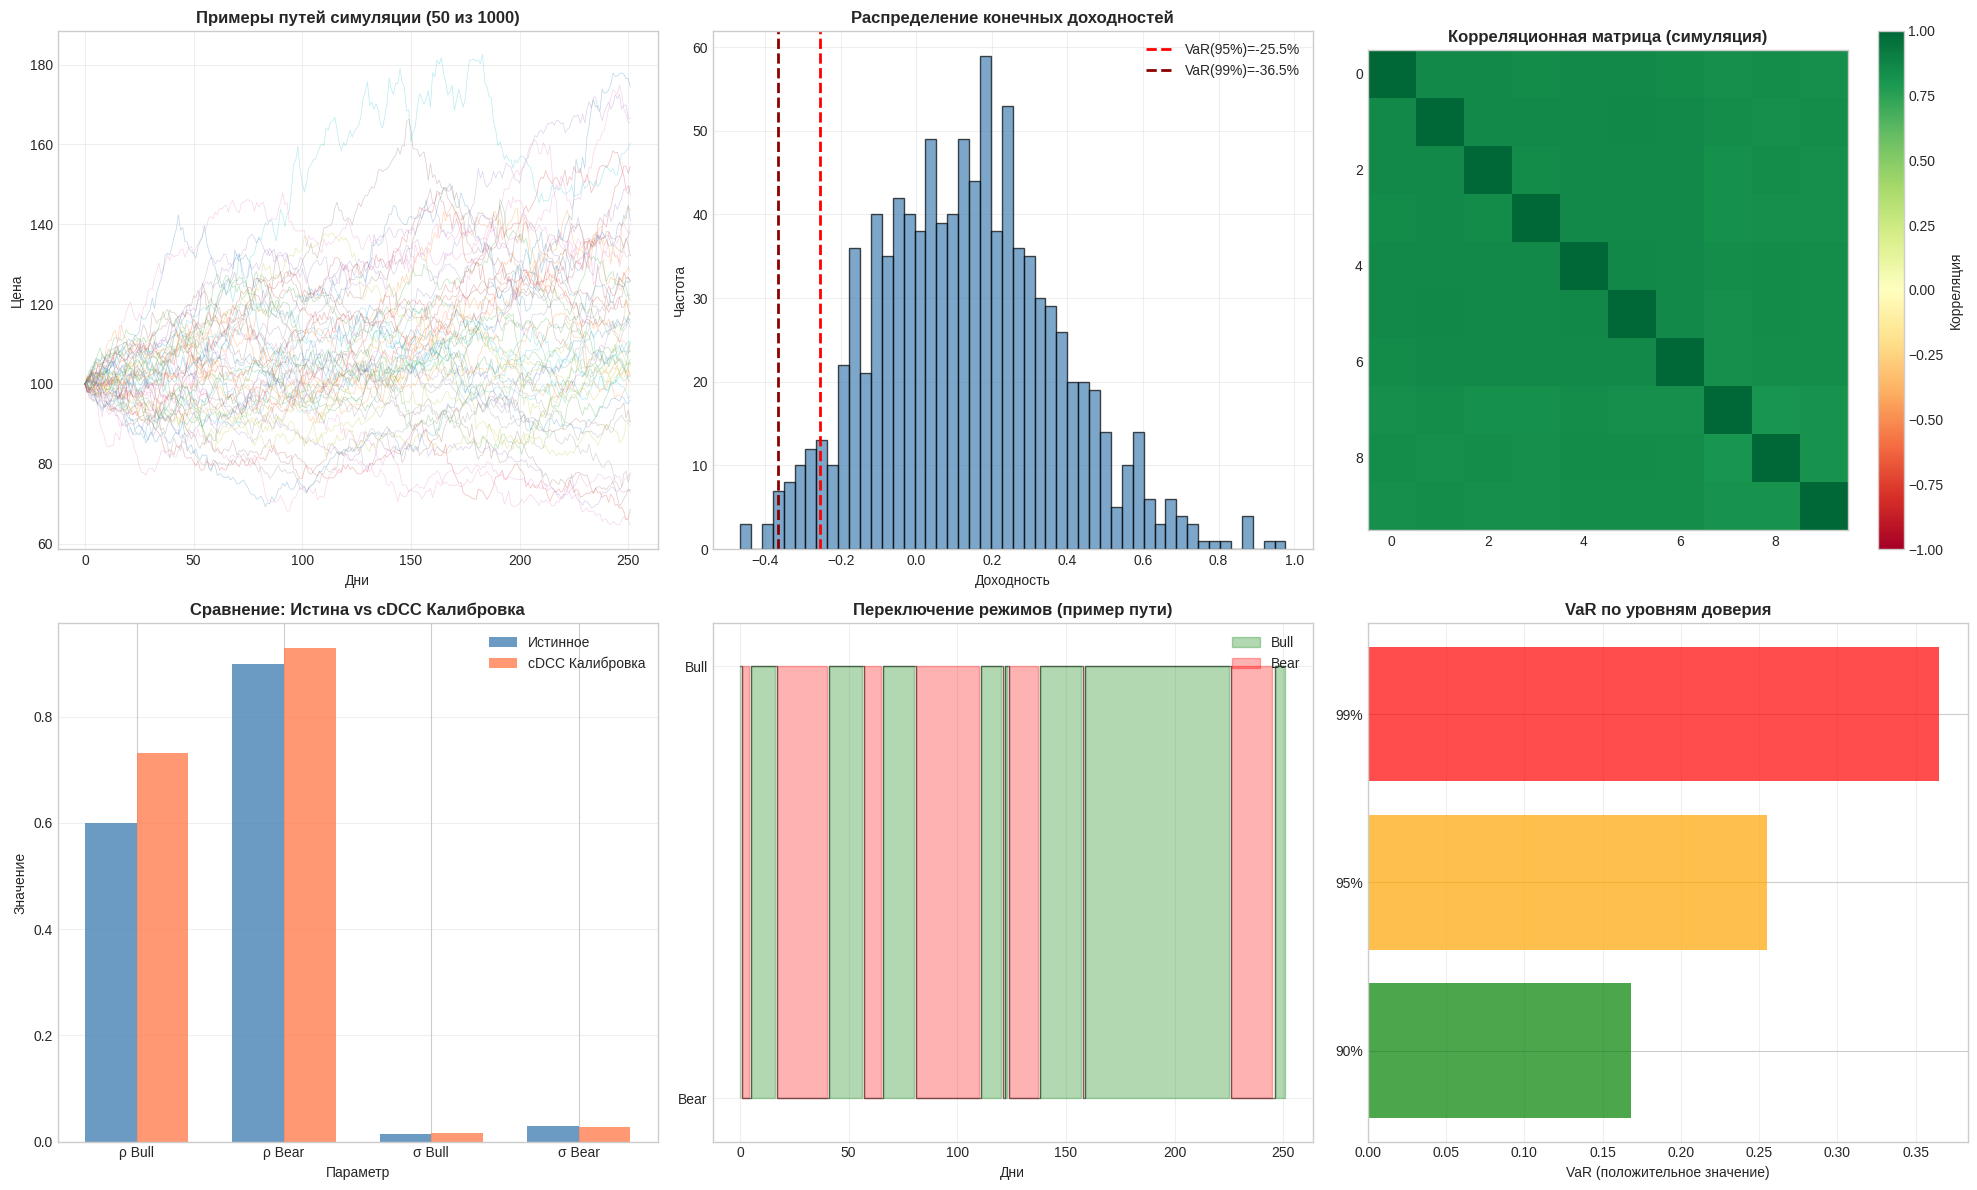

In [11]:
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(20, 12))

# 1. Примеры путей
ax1 = plt.subplot(2, 3, 1)
for i in range(min(50, N_PATHS)):
    plt.plot(simulated_paths[i, :, 0], alpha=0.3, linewidth=0.5)
plt.title(f'Примеры путей симуляции (50 из {N_PATHS})', fontsize=12, fontweight='bold')
plt.xlabel('Дни')
plt.ylabel('Цена')
plt.grid(True, alpha=0.3)

# 2. Распределение доходностей (final_returns)
ax2 = plt.subplot(2, 3, 2)
plt.hist(final_returns, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
plt.axvline(var_95, color='red', linestyle='--', linewidth=2, label=f'VaR(95%)={var_95:.1%}')
plt.axvline(var_99, color='darkred', linestyle='--', linewidth=2, label=f'VaR(99%)={var_99:.1%}')
plt.title('Распределение конечных доходностей', fontsize=12, fontweight='bold')
plt.xlabel('Доходность')
plt.ylabel('Частота')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Корреляционная матрица
ax3 = plt.subplot(2, 3, 3)
im = plt.imshow(sim_corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.title('Корреляционная матрица (симуляция)', fontsize=12, fontweight='bold')
plt.colorbar(im, label='Корреляция')
plt.grid(False)

# 4. Сравнение параметров
ax4 = plt.subplot(2, 3, 4)
params_to_compare = ['rho_bull', 'rho_bear', 'sigma_bull', 'sigma_bear']
x = np.arange(len(params_to_compare))
width = 0.35

true_vals = [TRUE_PARAMS[p] for p in params_to_compare]
calib_vals = [rho_bull, rho_bear, sigma_market_bull, sigma_market_bear]

plt.bar(x - width/2, true_vals, width, label='Истинное', alpha=0.8, color='steelblue')
plt.bar(x + width/2, calib_vals, width, label='cDCC Калибровка', alpha=0.8, color='coral')
plt.title('Сравнение: Истина vs cDCC Калибровка', fontsize=12, fontweight='bold')
plt.xlabel('Параметр')
plt.ylabel('Значение')
plt.xticks(x, ['ρ Bull', 'ρ Bear', 'σ Bull', 'σ Bear'])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# 5. Режимы
ax5 = plt.subplot(2, 3, 5)

# Генерация пути режимов
regime_path = []
current = 'bull'
for t in range(HORIZON):
    regime_path.append(current)
    current = simulator._next_regime(current)

regime_numeric = np.array([1 if r == 'bull' else 0 for r in regime_path])

# ← Лучший способ: step plot для режимов
ax5.step(range(HORIZON), regime_numeric, where='post',
         color='black', linewidth=1, alpha=0.5)

# Заполнение Bull
ax5.fill_between(range(HORIZON), 0, regime_numeric,
                 where=(regime_numeric == 1),
                 alpha=0.3, color='green', label='Bull')

# Заполнение Bear
ax5.fill_between(range(HORIZON), 0, 1,
                 where=(regime_numeric == 0),
                 alpha=0.3, color='red', label='Bear')

plt.title('Переключение режимов (пример пути)', fontsize=12, fontweight='bold')
plt.xlabel('Дни')
plt.yticks([0, 1], ['Bear', 'Bull'])  # ← Подписи оси Y
plt.ylim(-0.1, 1.1)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# 6. VaR
ax6 = plt.subplot(2, 3, 6)
var_levels = [90, 95, 99]
var_values = [np.percentile(final_returns, 100-l) for l in var_levels]
colors = ['green', 'orange', 'red']

plt.barh([str(l)+'%' for l in var_levels], [-v for v in var_values], color=colors, alpha=0.7)
plt.title('VaR по уровням доверия', fontsize=12, fontweight='bold')
plt.xlabel('VaR (положительное значение)')
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('simulation_results_cdcc_v5.png', dpi=150, bbox_inches='tight')
print("Визуализация сохранена в simulation_results_cdcc_v5.png")
plt.show()

## 9. Заключение

In [12]:
print(f"""
КАЛИБРОВКА cDCC-GARCH(1,1) ЗАВЕРШЕНА
   Акции: {N_ASSETS}
   Дней истории: {N_DAYS}
   Сходимость GARCH Bull: {sum(1 for g in garch_bull.values() if g and g['converged'])}/{N_ASSETS}
   Сходимость GARCH Bear: {sum(1 for g in garch_bear.values() if g and g['converged'])}/{N_ASSETS}
   cDCC параметры оценены: a={dcc_params_bull['a']:.4f}, b={dcc_params_bull['b']:.4f}
   Волатильность рынка: {sigma_market_bull:.4f} (Bull), {sigma_market_bear:.4f} (Bear)
   Beta Bull: {np.mean(list(beta_bull_dict.values())):.4f}, Beta Bear: {np.mean(list(beta_bear_dict.values())):.4f}
   Параметры сохранены: parameters.yaml

СИМУЛЯЦИЯ ЗАВЕРШЕНА
   Путей: {N_PATHS}
   Горизонт: {HORIZON} дней
   simulated_paths.shape: {simulated_paths.shape}
   Режимы: Bull={sum(h['bull'] for h in simulator.regime_history)/(N_PATHS*HORIZON):.1%}, Bear={sum(h['bear'] for h in simulator.regime_history)/(N_PATHS*HORIZON):.1%}
   NaN обнаружено: {simulator.nan_count}

ВАЛИДАЦИЯ
   VaR(95%): {var_95:.2%}
   VaR(99%): {var_99:.2%}
   Средняя корреляция: {sim_corr_mean:.4f}
   Средняя волатильность: {sim_vol:.4f}

СОХРАНЁННЫЕ ФАЙЛЫ
   parameters.yaml — полная калибровка с корреляционными матрицами
   simulated_paths_mean.csv — средние пути по дням
   path_statistics.csv — статистика по путям
   calibration_parameters.csv — параметры калибровки
   simulation_results_cdcc_v5.png — визуализация

""")


КАЛИБРОВКА cDCC-GARCH(1,1) ЗАВЕРШЕНА
   Акции: 10
   Дней истории: 750
   Сходимость GARCH Bull: 0/10
   Сходимость GARCH Bear: 0/10
   cDCC параметры оценены: a=0.0010, b=0.8000
   Волатильность рынка: 0.0157 (Bull), 0.0274 (Bear)
   Beta Bull: 1.3143, Beta Bear: 1.5768
   Параметры сохранены: parameters.yaml

СИМУЛЯЦИЯ ЗАВЕРШЕНА
   Путей: 1000
   Горизонт: 252 дней
   simulated_paths.shape: (1000, 252, 10)
   Режимы: Bull=70.3%, Bear=29.7%
   NaN обнаружено: 0

ВАЛИДАЦИЯ
   VaR(95%): -25.50%
   VaR(99%): -36.51%
   Средняя корреляция: 0.8430
   Средняя волатильность: 0.0140

СОХРАНЁННЫЕ ФАЙЛЫ
   parameters.yaml — полная калибровка с корреляционными матрицами
   simulated_paths_mean.csv — средние пути по дням
   path_statistics.csv — статистика по путям
   calibration_parameters.csv — параметры калибровки
   simulation_results_cdcc_v5.png — визуализация


